# Task 1

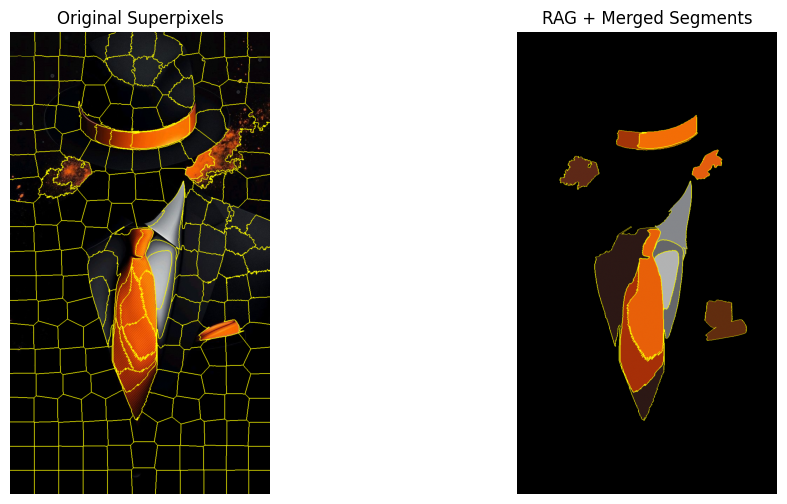

In [1]:
from skimage import io, color
from skimage.segmentation import slic, mark_boundaries
from skimage.graph import rag_mean_color, cut_threshold
import matplotlib.pyplot as plt
img = io.imread('your_image.jpg')
labels = slic(img, n_segments=200, compactness=10, start_label=0)
rag = rag_mean_color(img, labels)
labels_merged = cut_threshold(labels, rag, thresh=35)
out = color.label2rgb(labels_merged, img, kind='avg')
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.imshow(mark_boundaries(img, labels))
plt.title("Original Superpixels")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(out, labels_merged))
plt.title("RAG + Merged Segments")
plt.axis("off")
plt.show()

# Task 2

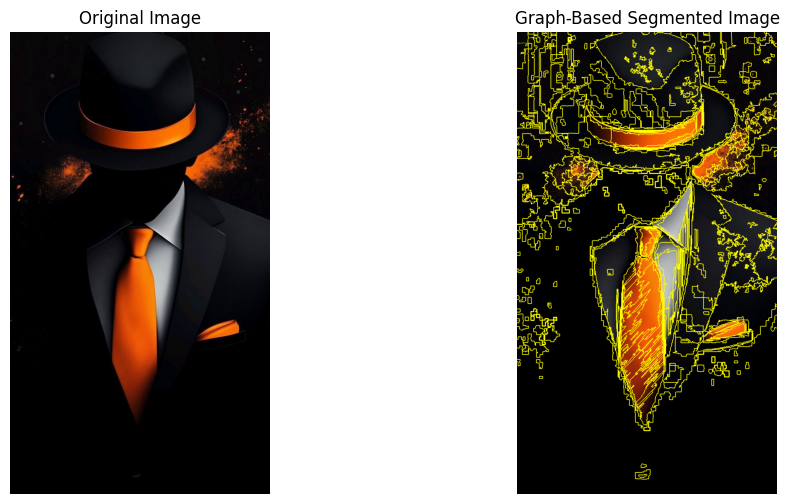

In [2]:
from skimage import io
from skimage.segmentation import felzenszwalb, mark_boundaries
import matplotlib.pyplot as plt
img = io.imread('your_image.jpg')
segments = felzenszwalb(img, scale=100, sigma=0.5, min_size=50)
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(img, segments))
plt.title("Graph-Based Segmented Image")
plt.axis("off")
plt.show()

# Task 3

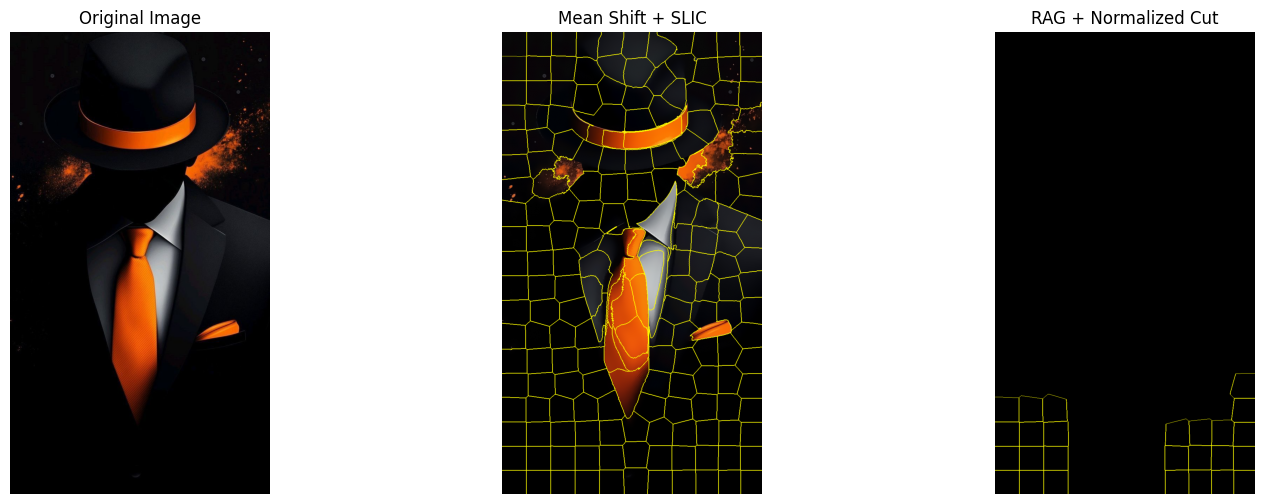

In [3]:
from skimage import io, color
from skimage.segmentation import slic, mark_boundaries
from skimage.graph import rag_mean_color, cut_normalized
import matplotlib.pyplot as plt
import cv2
img = io.imread('your_image.jpg')
smoothed_img = cv2.pyrMeanShiftFiltering(img, sp=10, sr=20)
labels_slic = slic(smoothed_img, n_segments=200, compactness=10, start_label=0)
rag = rag_mean_color(smoothed_img, labels_slic)
labels_merged = cut_normalized(labels_slic, rag)
out_final = color.label2rgb(labels_merged, img, kind='avg')
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(mark_boundaries(smoothed_img, labels_slic))
plt.title("Mean Shift + SLIC")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(mark_boundaries(out_final, labels_merged))
plt.title("RAG + Normalized Cut")
plt.axis("off")
plt.show()